<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 12 - Ejemplo 1 - Regresión logística
        </td>
    </tr>
    <tr>
 

</table>

In [2]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

El conjunto de datos Default contiene variables seleccionadas y datos de 10,000 usuarios de tarjetas de crédito. Las variables presentes son:

- student: Variable binaria que indica si un titular de tarjeta de crédito es estudiante o no.  
- income: Ingreso bruto anual del titular de la tarjeta de crédito.  
- balance: Saldo total de la tarjeta de crédito del usuario.  
- default: Variable binaria que indica si el usuario ha incumplido en el pago de su tarjeta de crédito.

El objetivo es ajustar un modelo que permita identificar los predictores relevantes del incumplimiento en tarjetas de crédito a partir de estas variables.

## Ejemplo 1 - Parte 1

1) Representar gráficamente las variables que conforman el dataset.
2) Crear un modelo de regresión logística considerando como variable independiente el balance y la variable dependiente a default.
3) Obtener las métricas asociadas al modelo para evaluar su eficacia.
4) Determinar si la varible independiente es significativa y evaluar la bondad del ajuste del modelo.
5) Representar la curva de probabilidades junto a las variables balance e income.
6) Clasficar como impago o no si se toma como observación la media del balance y luego para un balance de 2000.

In [4]:
data = pd.read_csv("Default.csv")
data

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
...,...,...,...,...
9995,No,No,711.555020,52992.378914
9996,No,No,757.962918,19660.721768
9997,No,No,845.411989,58636.156984
9998,No,No,1569.009053,36669.112365


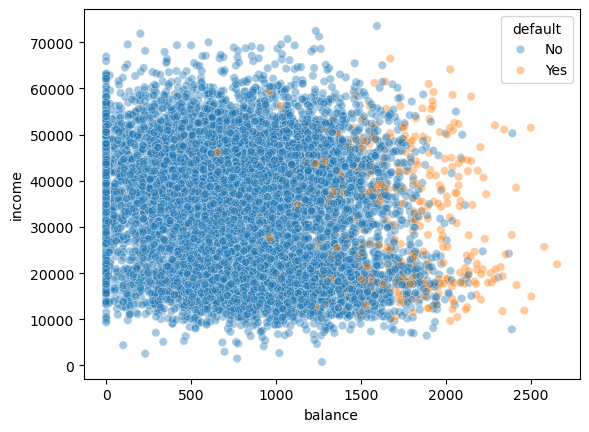

In [6]:
#1) Crear gráfico de dispersión clasificado por default
plt.figure()
sns.scatterplot(data=data, x="balance", y="income", hue="default", alpha=0.4)
plt.show()

Un análisis visual preliminar sugiere que, a medida que aumenta el balance, también se incrementa la probabilidad de que ocurra un impago en la cuota de la tarjeta de crédito.

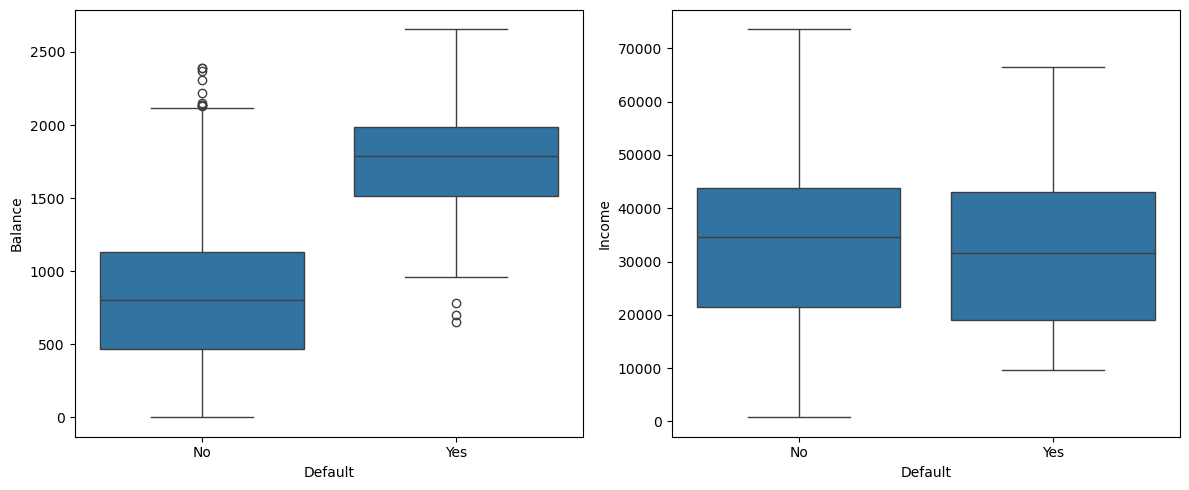

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para balance
sns.boxplot(x="default", y="balance", data=data, ax=axes[0])
axes[0].set_xlabel("Default")
axes[0].set_ylabel("Balance")

# Gráfico para income
sns.boxplot(x="default", y="income", data=data, ax=axes[1])
axes[1].set_xlabel("Default")
axes[1].set_ylabel("Income")

plt.tight_layout()
plt.show()

Antes de realizar el modelo de regresión logística es necesario convertir la variable default en indicadora. Para ello se crea una nueva columna, donde se coloca 1 si hay impago y 0 si no hay impago.

In [12]:
#2) Se importa la clase LogisticRegression
from sklearn.linear_model import LogisticRegression

x = data["balance"].values.reshape(-1,1)

#Crar variable indicadora para default
data["impago"] = [1 if x=="Yes" else 0 for x in data["default"]]
y = data["impago"]


logistic_reg = LogisticRegression(penalty=None)
logistic_reg.fit(x,y)

LogisticRegression(penalty=None)

In [14]:
#Obtener los parámetros del modelo
print("El coeficiente de la regresión es %s" %logistic_reg.coef_)

El coeficiente de la regresión es [[0.00549892]]


In [16]:
print("El intercepto de la regresión es %s" %logistic_reg.intercept_)

El intercepto de la regresión es [-10.65132867]


3) Las principales métricas a obtener serán:
 - El accuracy score
 - La matriz de confusión 
 - El valor de la precisión, recall y F1

In [19]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred = logistic_reg.predict(x)
accuracy = accuracy_score(y, y_pred)
print("El accuracy score que se tiene es %s" %accuracy)

El accuracy score que se tiene es 0.9725


Text(50.722222222222214, 0.5, 'Real')

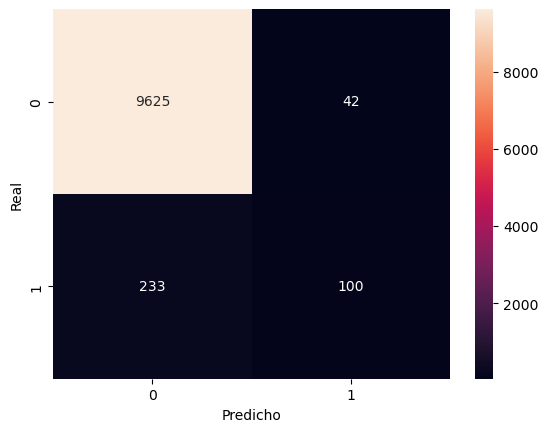

In [21]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision, recall,f1]})
metricas

,Métricas,Valores
0,Precisión,0.704225
1,Recall,0.300300
2,F1,0.421053


El modelo presenta un accuracy de 0.9725, lo que indica que clasifica correctamente el 97.25% de los casos. A primera vista, este valor parece muy alto; sin embargo, debe interpretarse con cuidado, ya que en problemas de impago suele existir un desbalance de clases, donde la mayoría de personas no caen en impago.

La matriz de confusión muestra que el modelo:

- clasifica correctamente 9625 casos de personas que no cayeron en impago,
- clasifica correctamente 100 casos de personas que sí cayeron en impago,
- comete 42 falsos positivos, es decir, predice impago cuando en realidad no lo hubo,
- y comete 233 falsos negativos, es decir, no detecta personas que realmente sí cayeron en impago.

La precisión es 0.7042, lo que significa que, de todas las personas que el modelo predijo como morosas, aproximadamente el 70.42% realmente estaban en impago.

El recall es 0.3003, lo cual indica que el modelo solo logra identificar correctamente el 30.03% de todos los casos reales de impago.

El F1-score es 0.4211, un valor moderado-bajo que refleja el equilibrio entre precisión y recall. En este caso, el F1-score evidencia que, aunque la precisión es aceptable, el bajo recall reduce el desempeño global del modelo para detectar impagos.r a quienes sí caen en mora.

In [43]:
import statsmodels.api as sm

#Añadir el intercepto
X2 = sm.add_constant(x)  

#Ajutar el modelo
est = sm.Logit(y, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 impago   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4534
Time:                        16:31:15   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.000     -11.359      -9.943
x1             0.0055      0

El modelo presenta un pseudo-$R^2$ de $0.4534$, lo que indica una capacidad explicativa relativamente alta para una regresión logística, sugiriendo que la variable independiente logra explicar una proporción importante de la variabilidad del impago; además, los p-valores tanto del modelo global como del coeficiente de $X_1$ evidencian que el modelo es estadísticamente significativo y que la variable considerada tiene un efecto relevante en la probabilidad de impago.

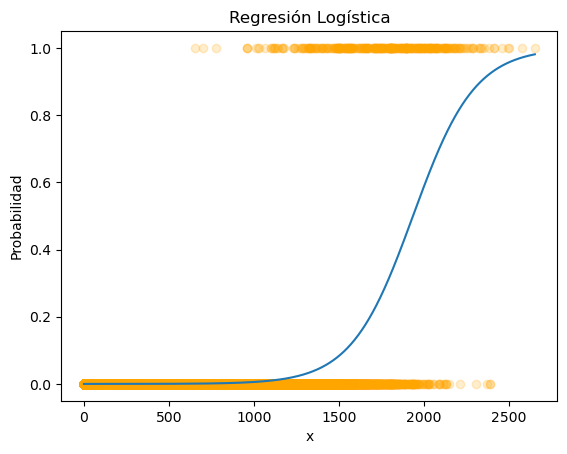

In [45]:
plt.scatter(x, y,alpha=0.2, c ="orange")

#Rango de valores para graficar
x_vals = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
y_prob = logistic_reg.predict_proba(x_vals)[:, 1] #Obtener la probabilidad
plt.plot(x_vals, y_prob)

plt.xlabel("x")
plt.ylabel("Probabilidad")
plt.title("Regresión Logística")
plt.show()

Se plantea clasificar una observación como impago o no impago utilizando el modelo de regresión logística estimado. Para ello, se evaluará en primer lugar la probabilidad de impago considerando como valor del predictor la media del balance, y posteriormente se realizará la misma clasificación para un valor específico de balance igual a 2000. 

In [47]:
#Obtener la media del balance
media_x = np.mean(x)
print("La media del balance es %4.5f" %media_x)

La media del balance es 835.37489


In [49]:
#Realizar la predicción
pred_media_x = logistic_reg.predict(media_x.reshape(-1,1))
print("La clase predicha para la media es %s" %pred_media_x)

La clase predicha para la media es [0]


In [51]:
#Obtener la probabilidad para la media
clase_predicha_media = logistic_reg.predict_proba(media_x.reshape(-1,1))

#Mostrar las probabilidades
print("La probabilidad de no caer en impago para el balance medio es %s" %clase_predicha_media[0,0])
print("La probabilidad de caer en impago para el balance medio es %s" %clase_predicha_media[0,1])

La probabilidad de no caer en impago para el balance medio es 0.9976656215331021
La probabilidad de caer en impago para el balance medio es 0.0023343784668978405


In [53]:
#Definir valor a predecir
x_nuevo = np.array([2000])
pred_x_nuevo = logistic_reg.predict(x_nuevo.reshape(-1,1))

print("La clase predicha para un balance de 2000 es %s" %pred_x_nuevo)

La clase predicha para un balance de 2000 es [1]


In [55]:
#Obtener la probabilidad para la media
clase_predicha_nuevo = logistic_reg.predict_proba(x_nuevo.reshape(-1,1))

#Mostrar las probabilidades
print("La probabilidad de no caer en impago para el balance medio es %s" %clase_predicha_nuevo[0,0])
print("La probabilidad de caer en impago para el balance medio es %s" %clase_predicha_nuevo[0,1])

La probabilidad de no caer en impago para el balance medio es 0.41423069975468263
La probabilidad de caer en impago para el balance medio es 0.5857693002453174


## Ejemplo 1 - Parte 2

1) Crear un modelo de regresión logística considerando como variables independientes el balance, el ingreso y si estudiante, y la variable dependiente a default.
2) Determinar las variables que son estadísticamente significativas y evaluar la bondad del ajuste del modelo.
3) Clasificar a una persona con un balance de 1500, ingresos de 40,000 y que es estudiante. Posteriormente tomar los mismos valores, pero en el caso que una persona no es estudiante.

Primeramente la variable student se debe convertir a indicadora, para ello se crea una nueva columna en el dataset y si la persona es estudiante se coloca 1, en caso contrario se indica con 0.

In [31]:
#Convertir la variable a indicadora
data["estudiante"] = [1 if x=="Yes" else 0 for x in data["student"]]
data

,default,student,balance,income,impago,estudiante
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0
3,No,No,529.250605,35704.493935,0,0
4,No,No,785.655883,38463.495879,0,0
...,...,...,...,...,...,...
9995,No,No,711.555020,52992.378914,0,0
9996,No,No,757.962918,19660.721768,0,0
9997,No,No,845.411989,58636.156984,0,0
9998,No,No,1569.009053,36669.112365,0,0


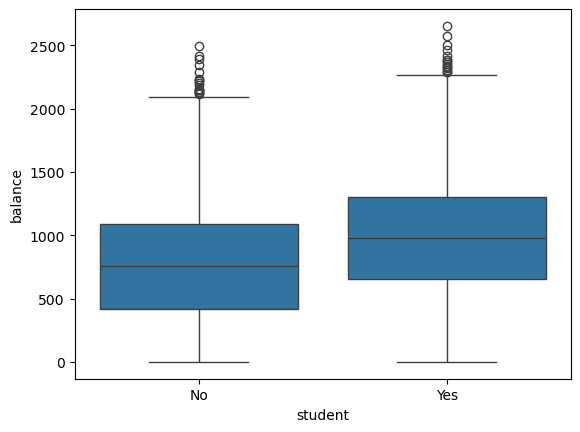

In [33]:
sns.boxplot(x="student", y="balance", data=data)
plt.show()

In [35]:
#Selccionar las variables independientes
x_independientes = data[["balance", "income", "estudiante"]]

logistic_reg_b = LogisticRegression()
logistic_reg_b.fit(x_independientes,y)

LogisticRegression()

In [37]:
#Mostrar el intercepto
print("El intercepto del modelo es %s" %logistic_reg_b.intercept_)

#Mostar los coeficientes
coefs_logistic_reg = pd.DataFrame({"Variable": x_independientes.columns, "Coeficientes":logistic_reg_b.coef_.flatten() })

El intercepto del modelo es [-10.90181161]


In [39]:
coefs_logistic_reg

,Variable,Coeficientes
0,balance,0.005731
1,income,0.000004
2,estudiante,-0.612564


In [41]:
y_pred_b = logistic_reg_b.predict(x_independientes)
accuracy_b = accuracy_score(y, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 0.9732


Text(50.722222222222214, 0.5, 'Real')

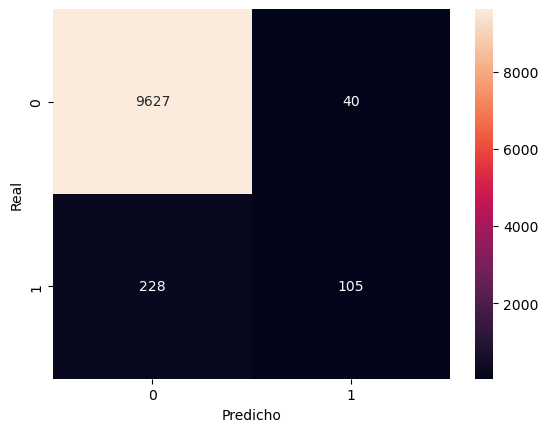

In [43]:
cm_b = confusion_matrix(y, y_pred_b)

sns.heatmap(cm_b, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [45]:
cm_b

array([[9627,   40],
       [ 228,  105]], dtype=int64)

In [77]:
precision_b = precision_score(y, y_pred_b)
recall_b = recall_score(y, y_pred_b)
f1_b = f1_score(y, y_pred_b)

metricas_b = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b,f1_b]})
metricas_b

,Métricas,Valores
0,Precisión,0.724138
1,Recall,0.315315
2,F1,0.439331


El modelo alcanza un accuracy de 0.9732, lo que significa que clasifica correctamente el 97.32% de las observaciones. Este valor es ligeramente superior al modelo anterior, lo que sugiere una pequeña mejora en el desempeño global.


La matriz de confusión indica que el modelo:

- clasifica correctamente 9627 personas que no cayeron en impago,
- clasifica correctamente 105 personas que sí cayeron en impago,
- comete 40 falsos positivos, es decir, predice impago cuando realmente no lo hubo,
- y comete 228 falsos negativos, es decir, no identifica personas que en realidad sí cayeron en impago.

La precisión es 0.7241, lo que significa que, de todas las personas clasificadas por el modelo como morosas, aproximadamente el 72.41% realmente se encontraban en impago.
El recall es 0.3153, lo cual indica que el modelo detecta correctamente el 31.53% de todos los casos reales de impago.
El F1-score es 0.4393, también ligeramente superior al obtenido antes. Esto refleja un mejor equilibrio entre precisión y recall, aunque el modelo todavía presenta limitaciones para capturar una mayor proporción de personas en impago.


In [67]:
import statsmodels.api as sm

#Añadir el intercepto
X2 = sm.add_constant(x_independientes)  

#Ajutar el modelo
est = sm.Logit(y, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 impago   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4619
Time:                        16:34:00   Log-Likelihood:                -785.77
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                3.257e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8690      0.492    -22.079      0.000     -11.834      -9.904
balance        0.0057      0

El modelo presenta un pseudo de $R^2$ de 0.4619, lo que indica una mejora en la capacidad explicativa respecto al modelo anterior, sugiriendo que las variables incluidas explican una proporción considerable de la variabilidad en el impago. En cuanto a los p-valores, el modelo global es altamente significativo, lo que confirma su validez estadística. A nivel individual, la variable balance resulta altamente significativa, evidenciando una fuerte relación con la probabilidad de impago, mientras que la variable estudiante también es significativa , indicando que tiene un efecto relevante en el modelo. Por otro lado, la variable income no es significativa, lo que sugiere que no aporta evidencia estadística suficiente para explicar el impago en presencia de las demás variables.

Se procede a estimar la probabilidad de impago utilizando el modelo de regresión logística para una persona con un balance de 1500, ingresos de 40,000 y condición de estudiante. Con base en la probabilidad obtenida, se determina si la observación se clasifica como impago o no impago. Posteriormente, se repite el mismo procedimiento manteniendo constantes el balance y los ingresos, pero cambiando la condición a no estudiante, con el fin de analizar cómo influye esta variable en la clasificación final.

In [50]:
x_nuevo2 = np.array([1500,40000, 1]).reshape(1,-1)
pred_2 = logistic_reg_b.predict(x_nuevo2)

print("La clase esperada para esta observación es %s" %pred_2)

proba_2 = logistic_reg_b.predict_proba(x_nuevo2)

#Mostrar las probabilidades
print("La probabilidad de no caer en impago es %s" %proba_2[0,0])
print("La probabilidad de caer en impago es %s" %proba_2[0,1])

La clase esperada para esta observación es [0]
La probabilidad de no caer en impago es 0.940475131795339
La probabilidad de caer en impago es 0.05952486820466092


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


In [51]:
x_nuevo3 = np.array([1500,40000, 0]).reshape(1,-1)
pred_3 = logistic_reg_b.predict(x_nuevo3)

print("La clase esperada para esta observación es %s" %pred_3)

proba_3 = logistic_reg_b.predict_proba(x_nuevo3)

print("La probabilidad de no caer en impago es %s" %proba_3[0,0])
print("La probabilidad de caer en impago es %s" %proba_3[0,1])

La clase esperada para esta observación es [0]
La probabilidad de no caer en impago es 0.8954280511654599
La probabilidad de caer en impago es 0.10457194883454009


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


## Fin